In [2]:
from preload import *
from scipy import stats
import statsmodels.formula.api as smf
linewidth=3
ticklabel_fontsize=25
label_fontsize=25
title_fontsize=22
title_x_postion=-.18
ylabel_y_postion=-1
labelpad=16
plt.rcParams['font.family']=['Helvetica']

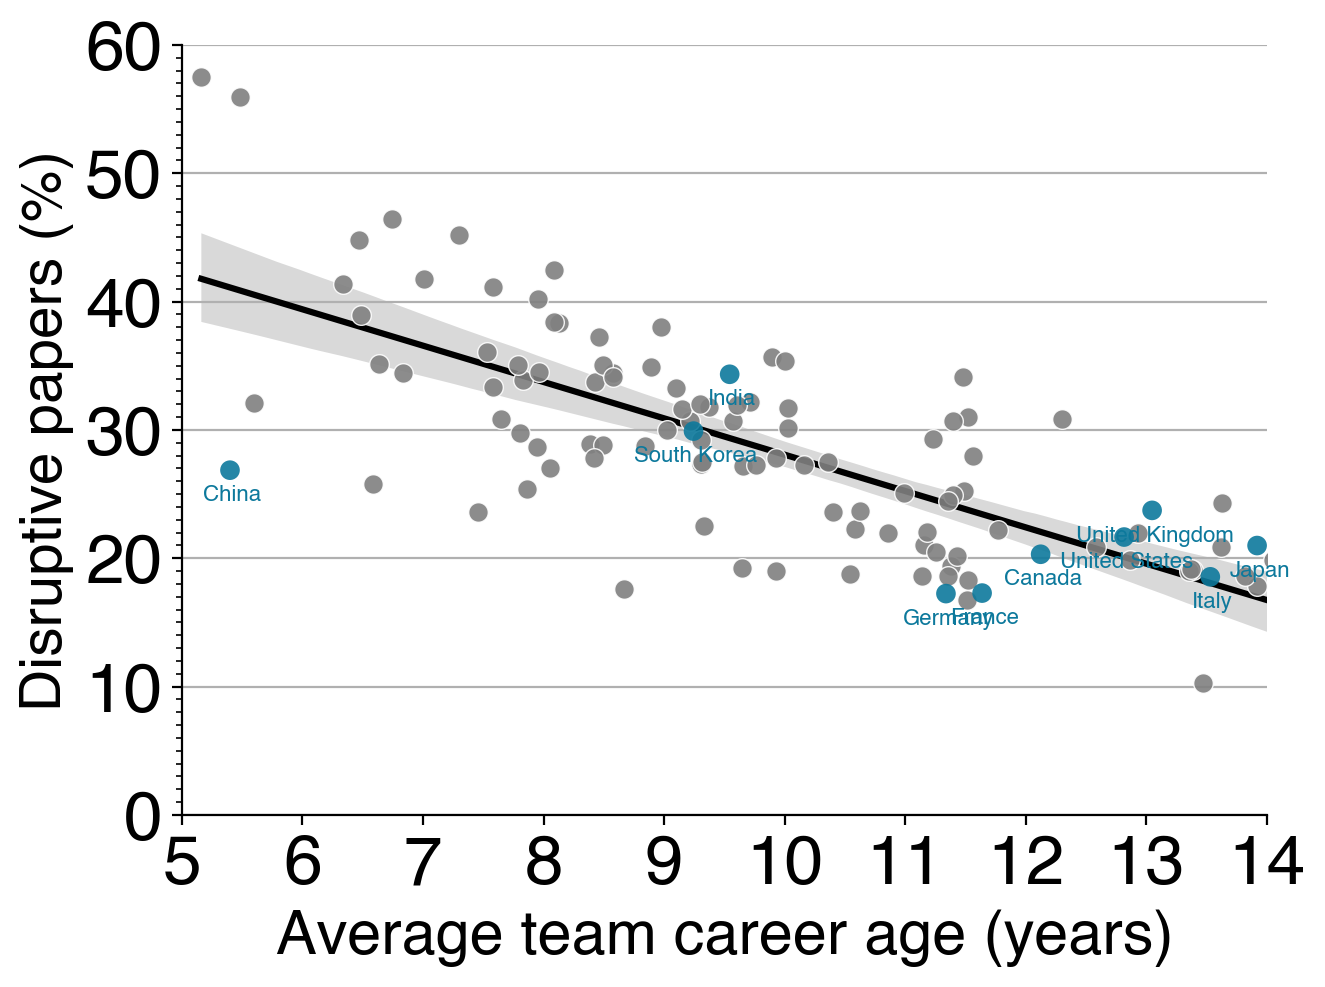

In [4]:
def myfun(x):
    return x/400+10
fig = plt.figure(figsize=(7,5),facecolor='white',dpi=200)
k=0
Data=pd.read_csv('./FigureData/FigureData3_2010_team_meanage.csv')
Data=Data[(Data['NumAuthors']>=200)]

tmp={country:[x,y,z] for x,y,z,country in zip(Data['Age'],Data['DisruptivePaper'],Data['NumPapers'],Data['Country'])}

sns.regplot(data=pd.DataFrame({'x':Data['Age'],'y':Data['DisruptivePaper'],'country':Data['Country']}),x='x',y='y',
            order=1,ci=95,
            color='k',
            scatter=False,
            line_kws={'color': 'k'},
            scatter_kws={'alpha':1,'s':myfun(Data['NumPapers']),
                         'edgecolors':'white','facecolor':'k'})
  
plt.ylabel('Disruptive papers (%)',fontsize=label_fontsize-4)
plt.xlabel('Average team career age (years)',fontsize=label_fontsize-3,y=ylabel_y_postion)
plt.ylim(0.,0.6)
plt.xlim(5,14)
ax= plt.gca()
ax.tick_params(axis='both', which='major', labelsize=ticklabel_fontsize)
ax.xaxis.set_minor_locator(plt.MultipleLocator(1))
ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.01))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.yticks([0,.1,0.2,0.3,0.4,0.5,0.6],['0','10','20','30','40','50','60'])

other_country=['United States', 'China', 'Japan','Germany','South Korea', 
       'France', 'United Kingdom', 'India', 'Canada', 'Italy', ]


for country in tmp:
    if country not in other_country:
        x,y,z = tmp[country]
        plt.scatter(x,y,zorder=100,
                    s=50,#s=myfun(z),
                    lw=0.5,
                    facecolor='gray',ec='w',alpha=.9)
fs=8


fc='#0D799C'
ffc='#0D799C'
for country,ccode in zip(other_country,other_country):
    if country in tmp:
        x,y,z = tmp[country]
        plt.scatter(x,y,zorder=100,s=50,color=fc,ec='none',alpha=.9)   
        plt.text(x+0.02,y-0.02,ccode,color=ffc,fontsize=fs,zorder=100,ha='center',va='center')
#plt.text(12,0.49,'2010',ha='right',fontsize=label_fontsize)
slope, intercept, r_value, p_value, std_err = stats.linregress(Data['Age'],Data['DisruptivePaper'])
plt.grid(axis='y')
plt.savefig('./fig/F3.pdf',bbox_inches='tight')